In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import cupy as cp

In [ ]:
# helper functions
def plot3d(X, Y, Z, title="3D Surface Plot"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("time")
    ax.set_ylabel("freqs")
    ax.set_zlabel("Data")
    plt.show()

In [3]:
freqs = pd.read_csv("data/Simulation/delz_MHz.csv", header=None).to_numpy().flatten()
time = pd.read_csv("data/Simulation/t_array.csv", header=None).to_numpy().flatten()

In [4]:
sim_data = pd.read_csv(
    "data/Simulation/transHport_t_vs_Bz_delx_0_dely_0.1.csv", header=None
)

In [ ]:
sim_data_np = sim_data.to_numpy()
grid = np.meshgrid(time, freqs, indexing="ij")
X, Y = grid
sim_data_np /= sim_data_np.max()

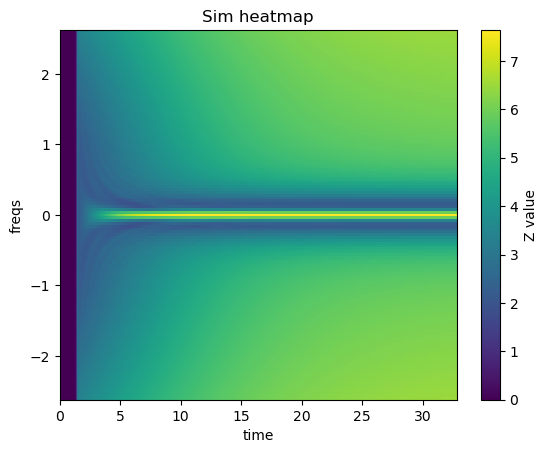

In [6]:
plt.pcolormesh(X, Y, sim_data_np, cmap="viridis")  # 'viridis' is a common colormap
plt.colorbar(label="Z value")
plt.title("Sim heatmap")
plt.xlabel("time")
plt.ylabel("freqs")
plt.show()

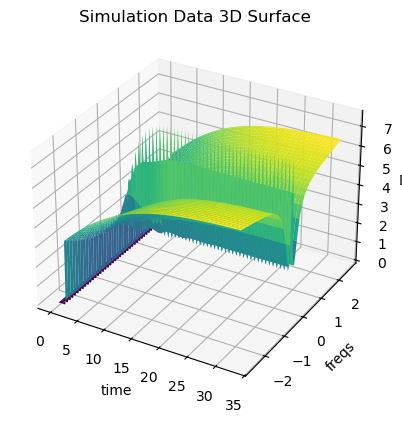

In [16]:
plot3d(X, Y, sim_data_np, title="Simulation Data 3D Surface")

# whats this spiky stuff? will it be amenable to interpolation?

In [13]:
exp_data = pd.read_csv("data/Experiment/Probe_trans_Exp.csv", header=None)
freqs_exp = (
    pd.read_csv("data/Experiment/Y_MHz_Exp.csv", header=None).to_numpy().flatten()
)
time_exp = pd.read_csv("data/Experiment/t_exp.csv", header=None).to_numpy().flatten()
grid_exp = np.meshgrid(time_exp, freqs_exp, indexing="ij")
X_exp, Y_exp = grid_exp
exp_data_np = exp_data.T.to_numpy()

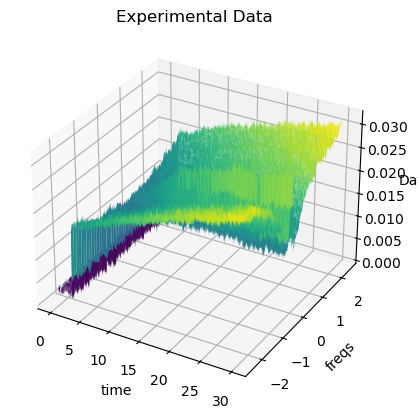

In [ ]:
plot3d(X_exp, Y_exp, exp_data_np, title="Experimental Data")

In [ ]:
# from cupyx.scipy.interpolate import RegularGridInterpolator

# def build_theory_interpolator_gpu(t_theory, f_theory, I_theory):
#     """
#     Build GPU interpolator from theory data.

#     Parameters:
#     -----------
#     t_theory, f_theory : 1D arrays (CPU)
#         Theory grid axes
#     I_theory : 2D array, shape (len(t_theory), len(f_theory))
#         Theoretical intensity values

#     Returns:
#     --------
#     interpolator : RegularGridInterpolator on GPU
#     """
#     t_gpu = cp.asarray(t_theory)
#     f_gpu = cp.asarray(f_theory)
#     I_gpu = cp.asarray(I_theory)

#     # Create interpolator (stays on GPU)
#     interpolator = RegularGridInterpolator(
#         (t_gpu, f_gpu),
#         I_gpu,
#         method='linear',
#         bounds_error=False,
#         fill_value=0.0  # or cp.nan
#     )

#     return interpolator


# def calculate_likelihood_gpu(I_measured_trace_gpu, B_grid_unknown_gpu, f_bias,
#                              t_axis_exp_gpu, theory_interpolator_gpu, sigma_gpu):
#     """
#     Calculates likelihood vector - ALL ON GPU with built-in interpolation.
#     """
#     # Create f_total grid
#     f_total_grid_gpu = B_grid_unknown_gpu + f_bias

#     # Create meshgrid
#     T_mesh_gpu, F_mesh_gpu = cp.meshgrid(t_axis_exp_gpu, f_total_grid_gpu, indexing='ij')

#     # Stack into shape (M_time * K_grid, 2) for interpolator
#     points = cp.stack([T_mesh_gpu.ravel(), F_mesh_gpu.ravel()], axis=-1)

#     # Interpolate on GPU!
#     I_theory_flat = theory_interpolator_gpu(points)
#     I_theory_matrix_gpu = I_theory_flat.reshape(len(t_axis_exp_gpu), len(f_total_grid_gpu))

#     # Calculate log-likelihood
#     I_measured_col_gpu = I_measured_trace_gpu[:, cp.newaxis]
#     sum_sq_errors = cp.sum((I_measured_col_gpu - I_theory_matrix_gpu)**2, axis=0)
#     log_L = -sum_sq_errors / (2 * sigma_gpu**2)

#     # Normalize
#     L = cp.exp(log_L - cp.max(log_L))

#     return L


# def update_posterior_gpu(prior_gpu, I_measured_trace_gpu, B_grid_unknown_gpu, f_bias,
#                          t_axis_exp_gpu, theory_interpolator_gpu, sigma_gpu):
#     """
#     Bayesian update - ALL ON GPU.
#     """
#     L = calculate_likelihood_gpu(I_measured_trace_gpu, B_grid_unknown_gpu, f_bias,
#                                  t_axis_exp_gpu, theory_interpolator_gpu, sigma_gpu)

#     post = prior_gpu * L
#     post_sum = cp.trapz(post, B_grid_unknown_gpu)

#     if post_sum > 1e-12:
#         post /= post_sum
#     else:
#         print("Warning: Posterior sum is zero. Re-initializing to uniform.")
#         post = cp.ones_like(B_grid_unknown_gpu) / (B_grid_unknown_gpu[-1] - B_grid_unknown_gpu[0])

#     return post


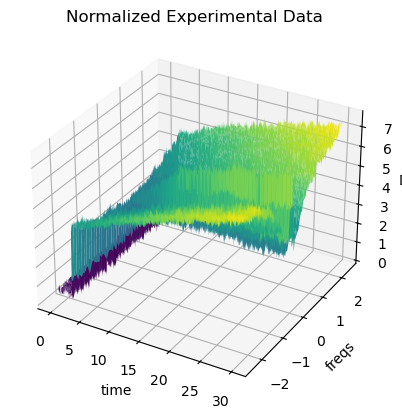

In [ ]:
# def run_offline_analysis_gpu(
#     sim, exp,
#     sigma_noise=0.01,
#     f_range_unknown=(-1.0, 1.0),
#     grid_resolution=0.002,
#     return_cpu=True
# ):
#     # 1. Load theory model (CPU) and create interpolator
#     t_sim, f_sim, I_sim = sim['time'], sim['freq'], sim['data']
#     # if theory_interp is None:
#     #     return None

#     # 2. Load experiment (CPU)
#     t_exp, f_exp_bias, I_exp = exp['time'], exp['freq'], exp['data']

#     # 3. Allocate GPU versions only once
#     f_grid = cp.arange(f_range_unknown[0], f_range_unknown[1],
#                        grid_resolution, dtype=cp.float64) # type: ignore
#     n_f = f_grid.size

#     prior = cp.ones(n_f, dtype=cp.float64)
#     prior /= prior.sum()  # uniform discrete prior

#     t_exp_gpu = cp.asarray(t_exp, dtype=cp.float64)
#     I_exp_gpu = cp.asarray(I_exp, dtype=cp.float64)
#     sigma_noise_gpu = cp.asarray(sigma_noise, dtype=cp.float64)

#     N_exp = len(f_exp_bias)

#     # Preallocate results (on GPU)
#     posteriors_gpu = [prior]  # keep GPU references
#     Means = cp.zeros(N_exp, dtype=cp.float64)
#     Modes = cp.zeros(N_exp, dtype=cp.float64)
#     StdDevs = cp.zeros(N_exp, dtype=cp.float64)

#     # 4. Sequential Bayesian update
#     for i in range(N_exp):
#         f_bias = f_exp_bias[i]

#         trace_gpu = I_exp_gpu[:, i]  # GPU time trace

#         # compute likelihood
#         L = compute_likelihood_gpu()
#         # compute posterior on GPU
#         posterior = update_posterior_gpu(
#             prior, trace_gpu, f_grid, f_bias,
#             t_exp_gpu, I_sim, sigma_noise_gpu
#         )

#         # normalize
#         posterior /= posterior.sum()

#         # compute GPU summary stats
#         Means[i] = cp.sum(f_grid * posterior)

#         # mode
#         idx = cp.argmax(posterior)
#         Modes[i] = f_grid[idx]
#         # stddev
#         StdDevs[i] = cp.sqrt(cp.sum((f_grid - Means[i])**2 * posterior))

#         # push posterior forward
#         prior = posterior
#         posteriors_gpu.append(posterior)

#     # 5. Return GPU or CPU copies as needed
#     if not return_cpu:
#         return f_grid, posteriors_gpu, f_exp_bias, Means, Modes, StdDevs

#     # CPU versions (copied once)
#     f_grid_cpu = cp.asnumpy(f_grid)
#     posts_cpu = [cp.asnumpy(p) for p in posteriors_gpu]
#     Means_cpu = cp.asnumpy(Means)
#     Modes_cpu = cp.asnumpy(Modes)
#     StdDevs_cpu = cp.asnumpy(StdDevs)

#     return f_grid_cpu, posts_cpu, f_exp_bias, Means_cpu, Modes_cpu, StdDevs_cpu


In [8]:
# interpolate data
# function to plot data


# i dont know what is going on. what is the experiment? i have the interpolated sum, and now what?
# we interpolate the data, take a subset of it: say out of 3000 points, we only take a window of 1000 somewhere
# that forms our B_unk array, and that puts us on parity with the previous experiments where we had a theoretical expression of alpha for every B


In [19]:
from cupyx.scipy.interpolate import RegularGridInterpolator


def run_offline_analysis_gpu(
    sim,
    exp,
    sigma_noise=0.01,
    f_range_unknown=(-1.0, 1.0),
    grid_resolution=0.002,
    return_cpu=True,
):
    """
    Run Bayesian field estimation entirely on GPU using RegularGridInterpolator.

    Parameters:
    -----------
    sim : dict
        Simulation data with keys 'time', 'freq', 'data'
        sim['data'] should be 2D array with shape (len(time), len(freq))
    exp : dict
        Experimental data with keys 'time', 'freq', 'data'
        exp['data'] should be 2D array with shape (len(time), len(freq_bias))
    sigma_noise : float
        Measurement noise standard deviation
    f_range_unknown : tuple
        (min, max) range for unknown field grid
    grid_resolution : float
        Grid spacing for unknown field hypotheses
    return_cpu : bool
        If True, return numpy arrays; if False, return cupy arrays

    Returns:
    --------
    f_grid : array
        Grid of unknown field values
    posteriors : list of arrays
        Posterior distributions at each step
    f_exp_bias : array
        Experimental bias frequencies
    Means, Modes, StdDevs : arrays
        Summary statistics for each posterior
    """

    # 1. Build theory interpolator on GPU (one-time setup)
    t_sim_gpu = cp.asarray(sim["time"], dtype=cp.float64)
    f_sim_gpu = cp.asarray(sim["freq"], dtype=cp.float64)
    I_sim_gpu = cp.asarray(sim["data"], dtype=cp.float64)

    theory_interpolator_gpu = RegularGridInterpolator(
        (t_sim_gpu, f_sim_gpu),
        I_sim_gpu,
        method="linear",
        bounds_error=False,
        fill_value=0.0,
    )

    # 2. Load experimental data to GPU
    t_exp_gpu = cp.asarray(exp["time"], dtype=cp.float64)
    f_exp_bias = exp["freq"]  # Keep on CPU for now (used for indexing)
    I_exp_gpu = cp.asarray(exp["data"], dtype=cp.float64)
    sigma_noise_gpu = cp.float64(sigma_noise)

    # 3. Initialize unknown field grid and prior on GPU
    f_grid_gpu = cp.arange(
        f_range_unknown[0],
        f_range_unknown[1],
        grid_resolution,  # type: ignore
        dtype=cp.float64,
    )
    n_f = f_grid_gpu.size

    # Uniform prior
    prior_gpu = cp.ones(n_f, dtype=cp.float64)
    prior_gpu /= cp.trapz(prior_gpu, f_grid_gpu)  # Normalize with simpson

    # 4. Preallocate results on GPU
    N_exp = len(f_exp_bias)
    posteriors_gpu = [prior_gpu.copy()]
    Means_gpu = cp.zeros(N_exp, dtype=cp.float64)
    Modes_gpu = cp.zeros(N_exp, dtype=cp.float64)
    StdDevs_gpu = cp.zeros(N_exp, dtype=cp.float64)

    # 5. Sequential Bayesian update loop
    for i in range(N_exp):
        f_bias = float(f_exp_bias[i])
        trace_gpu = I_exp_gpu[:, i]  # Intensity trace for this bias frequency

        # Update posterior (all on GPU)
        posterior_gpu = update_posterior_gpu(
            prior_gpu,
            trace_gpu,
            f_grid_gpu,
            f_bias,
            t_exp_gpu,
            theory_interpolator_gpu,
            sigma_noise_gpu,
        )

        # Compute summary statistics on GPU
        Means_gpu[i] = cp.sum(f_grid_gpu * posterior_gpu) * grid_resolution

        # Mode (maximum of posterior)
        idx_mode = cp.argmax(posterior_gpu)
        Modes_gpu[i] = f_grid_gpu[idx_mode]

        # Standard deviation
        variance = (
            cp.sum((f_grid_gpu - Means_gpu[i]) ** 2 * posterior_gpu) * grid_resolution
        )
        StdDevs_gpu[i] = cp.sqrt(variance)

        # Update prior for next iteration
        prior_gpu = posterior_gpu
        posteriors_gpu.append(posterior_gpu.copy())

    # 6. Return results (GPU or CPU)
    if not return_cpu:
        return (
            f_grid_gpu,
            posteriors_gpu,
            f_exp_bias,
            Means_gpu,
            Modes_gpu,
            StdDevs_gpu,
        )

    # Transfer to CPU
    f_grid_cpu = cp.asnumpy(f_grid_gpu)
    posteriors_cpu = [cp.asnumpy(p) for p in posteriors_gpu]
    Means_cpu = cp.asnumpy(Means_gpu)
    Modes_cpu = cp.asnumpy(Modes_gpu)
    StdDevs_cpu = cp.asnumpy(StdDevs_gpu)

    return (f_grid_cpu, posteriors_cpu, f_exp_bias, Means_cpu, Modes_cpu, StdDevs_cpu)


def update_posterior_gpu(
    prior_gpu,
    I_measured_trace_gpu,
    f_grid_gpu,
    f_bias,
    t_exp_gpu,
    theory_interpolator_gpu,
    sigma_gpu,
):
    """
    Bayesian update using RegularGridInterpolator - ALL ON GPU.

    Parameters:
    -----------
    prior_gpu : cupy array, shape (K_grid,)
        Prior distribution over unknown field
    I_measured_trace_gpu : cupy array, shape (M_time,)
        Measured intensity trace
    f_grid_gpu : cupy array, shape (K_grid,)
        Grid of unknown field hypotheses
    f_bias : float
        Bias frequency for this measurement
    t_exp_gpu : cupy array, shape (M_time,)
        Experimental time axis
    theory_interpolator_gpu : RegularGridInterpolator
        Theory model interpolator (on GPU)
    sigma_gpu : float
        Measurement noise standard deviation

    Returns:
    --------
    posterior_gpu : cupy array, shape (K_grid,)
        Normalized posterior distribution
    """
    # Calculate likelihood
    L_gpu = calculate_likelihood_gpu(
        I_measured_trace_gpu,
        f_grid_gpu,
        f_bias,
        t_exp_gpu,
        theory_interpolator_gpu,
        sigma_gpu,
    )

    # Bayesian update
    posterior_gpu = prior_gpu * L_gpu

    # Normalize using Simpson's rule
    post_sum = cp.trapz(posterior_gpu, f_grid_gpu)

    if post_sum > 1e-12:
        posterior_gpu /= post_sum
    else:
        print(f"Warning: Posterior sum is {post_sum:.2e}. Re-initializing to uniform.")
        dx = f_grid_gpu[1] - f_grid_gpu[0]
        posterior_gpu = cp.ones_like(f_grid_gpu) / (len(f_grid_gpu) * dx)

    return posterior_gpu


def calculate_likelihood_gpu(
    I_measured_trace_gpu,
    f_grid_gpu,
    f_bias,
    t_exp_gpu,
    theory_interpolator_gpu,
    sigma_gpu,
):
    """
    Calculate likelihood for all field hypotheses using GPU interpolator.

    Parameters:
    -----------
    I_measured_trace_gpu : cupy array, shape (M_time,)
        Measured intensity trace
    f_grid_gpu : cupy array, shape (K_grid,)
        Grid of unknown field hypotheses
    f_bias : float
        Bias frequency
    t_exp_gpu : cupy array, shape (M_time,)
        Experimental time axis
    theory_interpolator_gpu : RegularGridInterpolator
        Theory interpolator on GPU
    sigma_gpu : float
        Measurement noise std dev

    Returns:
    --------
    L_gpu : cupy array, shape (K_grid,)
        Normalized likelihood for each hypothesis
    """
    # Create total frequency grid
    f_total_grid_gpu = f_grid_gpu + f_bias

    # Create meshgrid for all (t, f_total) evaluation points
    T_mesh_gpu, F_mesh_gpu = cp.meshgrid(t_exp_gpu, f_total_grid_gpu, indexing="ij")

    # Stack into shape (M_time * K_grid, 2) for interpolator
    points_gpu = cp.stack([T_mesh_gpu.ravel(), F_mesh_gpu.ravel()], axis=-1)

    # Interpolate theory on GPU
    I_theory_flat_gpu = theory_interpolator_gpu(points_gpu)
    I_theory_matrix_gpu = I_theory_flat_gpu.reshape(len(t_exp_gpu), len(f_grid_gpu))

    # Calculate log-likelihood
    I_measured_col_gpu = I_measured_trace_gpu[:, cp.newaxis]
    sum_sq_errors_gpu = cp.sum((I_measured_col_gpu - I_theory_matrix_gpu) ** 2, axis=0)
    log_L_gpu = -sum_sq_errors_gpu / (2 * sigma_gpu**2)

    # Normalize for numerical stability
    L_gpu = cp.exp(log_L_gpu - cp.max(log_L_gpu))

    return L_gpu

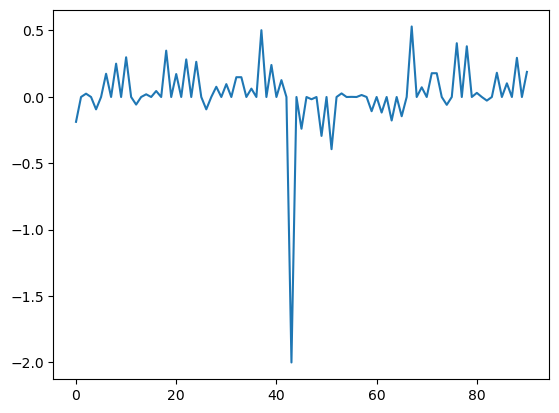

In [26]:
sim = {"time": time, "freq": freqs, "data": sim_data_np}

exp = {"time": time_exp, "freq": freqs_exp, "data": exp_data_np}

f_grid, posteriors, f_exp_bias, Means, Modes, StdDevs = run_offline_analysis_gpu(
    sim,
    exp,
    sigma_noise=0.01,
    f_range_unknown=(-1.0, 1.0),
    grid_resolution=0.002,
    return_cpu=True,
)

plt.plot(Means)